<a href="https://colab.research.google.com/github/hsarrah-create/Assignment-1/blob/main/ass2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("derived_event_log_complaint_management.csv")

print("Rows:", len(df))
print("Cases:", df["Case ID"].nunique())

print("\nColumns:")
print(df.columns.tolist())

print("\nSample:")
print(df.head())

Rows: 85284
Cases: 21321

Columns:
['Case ID', 'Activity', 'Timestamp', 'Timestamp Type', 'Event Order']

Sample:
      Case ID                  Activity        Timestamp  \
0  6168884918              Order Placed  9/10/2024 23:38   
1  6168884918  Ready Marked - Correctly  9/10/2024 23:56   
2  6168884918  Order Status - Delivered              NaN   
3  6168884918              No Complaint              NaN   
4  6170707559              Order Placed  9/10/2024 23:34   

                       Timestamp Type  Event Order  
0                            Observed            1  
1  Derived from Order Placed At + KPT            2  
2             Not available in source            3  
3             Not available in source            4  
4                            Observed            1  


In [ ]:
import pandas as pd

df = pd.read_csv("derived_event_log_complaint_management.csv")

print("Rows:", len(df))
print("Cases:", df["Case ID"].nunique())

print("\nColumns:")
print(df.columns.tolist())

print("\nSample:")
print(df.head())

Rows: 85284
Cases: 21321

Columns:
['Case ID', 'Activity', 'Timestamp', 'Timestamp Type', 'Event Order']

Sample:
      Case ID                  Activity        Timestamp  \
0  6168884918              Order Placed  9/10/2024 23:38   
1  6168884918  Ready Marked - Correctly  9/10/2024 23:56   
2  6168884918  Order Status - Delivered              NaN   
3  6168884918              No Complaint              NaN   
4  6170707559              Order Placed  9/10/2024 23:34   

                       Timestamp Type  Event Order  
0                            Observed            1  
1  Derived from Order Placed At + KPT            2  
2             Not available in source            3  
3             Not available in source            4  
4                            Observed            1  


In [ ]:
# Create one row per case and define the prediction target

case_target = (
    df.groupby("Case ID")["Activity"]
      .apply(lambda x: 0 if "No Complaint" in x.values else 1)
      .reset_index(name="Complaint")
)

print("Number of cases:", len(case_target))
print("\nTarget distribution:")
print(case_target["Complaint"].value_counts())

print("\nTarget percentage:")
print((case_target["Complaint"].value_counts(normalize=True) * 100).round(2))

Number of cases: 21321

Target distribution:
Complaint
0    20852
1      469
Name: count, dtype: int64

Target percentage:
Complaint
0    97.8
1     2.2
Name: proportion, dtype: float64


In [ ]:
for order in sorted(df["Event Order"].unique()):
    print(f"\nEvent Order {order}:")
    print(
        df[df["Event Order"] == order]["Activity"]
        .value_counts()
    )


Event Order 1:
Activity
Order Placed    21321
Name: count, dtype: int64

Event Order 2:
Activity
Ready Marked - Correctly      19087
Ready Marked - Incorrectly     1895
Ready Marked - Missed           339
Name: count, dtype: int64

Event Order 3:
Activity
Order Status - Delivered           21131
Order Status - Rejected              158
Order Status - Returned               25
Order Status - Return cancelled        3
Order Status - Picked up               3
Order Status - Timed out               1
Name: count, dtype: int64

Event Order 4:
Activity
No Complaint                                    20852
Complaint - Non-refunded complaint                157
Complaint - Poor taste or quality                 120
Complaint - Poor packaging or spillage            104
Complaint - Wrong item(s) delivered                48
Complaint - Item(s) missing or not delivered       40
Name: count, dtype: int64


In [ ]:
# Convert Timestamp to datetime
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

# Event 1: Order Placed
order_placed = (
    df[df["Event Order"] == 1]
    [["Case ID", "Timestamp"]]
    .rename(columns={"Timestamp": "Order_Placed_Time"})
)

# Event 2: Readiness
readiness = (
    df[df["Event Order"] == 2]
    [["Case ID", "Activity", "Timestamp"]]
    .rename(columns={
        "Activity": "Readiness_Status",
        "Timestamp": "Readiness_Time"
    })
)

# Event 3: Order Status
order_status = (
    df[df["Event Order"] == 3]
    [["Case ID", "Activity"]]
    .rename(columns={"Activity": "Order_Status"})
)

# Merge everything with the target
model_df = (
    case_target
    .merge(order_placed, on="Case ID")
    .merge(readiness, on="Case ID")
    .merge(order_status, on="Case ID")
)

# Calculate preparation time in minutes
model_df["Preparation_Time_Min"] = (
    model_df["Readiness_Time"] -
    model_df["Order_Placed_Time"]
).dt.total_seconds() / 60

print("Shape:", model_df.shape)

print("\nColumns:")
print(model_df.columns.tolist())

print("\nMissing values:")
print(model_df.isna().sum())

print("\nSample:")
print(model_df.head())

Shape: (21321, 7)

Columns:
['Case ID', 'Complaint', 'Order_Placed_Time', 'Readiness_Status', 'Readiness_Time', 'Order_Status', 'Preparation_Time_Min']

Missing values:
Case ID                   0
Complaint                 0
Order_Placed_Time         0
Readiness_Status          0
Readiness_Time          295
Order_Status              0
Preparation_Time_Min    295
dtype: int64

Sample:
      Case ID  Complaint   Order_Placed_Time          Readiness_Status  \
0  6086766700          0 2024-09-14 01:48:00  Ready Marked - Correctly   
1  6116926909          0 2024-09-07 21:26:00  Ready Marked - Correctly   
2  6117745852          0 2024-09-01 12:34:00  Ready Marked - Correctly   
3  6120064321          0 2024-09-04 13:12:00  Ready Marked - Correctly   
4  6121426551          0 2024-09-02 16:25:00  Ready Marked - Correctly   

       Readiness_Time              Order_Status  Preparation_Time_Min  
0 2024-09-14 02:53:00  Order Status - Delivered                  65.0  
1 2024-09-07 21:46:00  O

In [ ]:
# Keep only the features used for prediction
X = model_df[
    ["Readiness_Status", "Order_Status", "Preparation_Time_Min"]
].copy()

y = model_df["Complaint"].copy()

# Fill missing preparation time with the median
median_prep_time = X["Preparation_Time_Min"].median()
X["Preparation_Time_Min"] = X["Preparation_Time_Min"].fillna(median_prep_time)

print("Median used:", median_prep_time)
print("Missing values after filling:")
print(X.isna().sum())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Median used: 16.0
Missing values after filling:
Readiness_Status        0
Order_Status            0
Preparation_Time_Min    0
dtype: int64

X shape: (21321, 3)
y shape: (21321,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Readiness_Status", "Order_Status"]
numeric_features = ["Preparation_Time_Min"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training cases:", len(X_train))
print("Testing cases:", len(X_test))

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training cases: 17056
Testing cases: 4265

Training target:
Complaint
0    16681
1      375
Name: count, dtype: int64

Testing target:
Complaint
0    4171
1      94
Name: count, dtype: int64


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

print("Logistic Regression")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic, digits=4))

Logistic Regression

Confusion Matrix:
[[1786 2385]
 [  38   56]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9792    0.4282    0.5958      4171
           1     0.0229    0.5957    0.0442        94

    accuracy                         0.4319      4265
   macro avg     0.5011    0.5120    0.3200      4265
weighted avg     0.9581    0.4319    0.5837      4265



In [ ]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        class_weight="balanced",
        max_depth=5,
        random_state=42
    ))
])

decision_tree_model.fit(X_train, y_train)

y_pred_tree = decision_tree_model.predict(X_test)

print("Decision Tree")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree, digits=4))

Decision Tree

Confusion Matrix:
[[3489  682]
 [  76   18]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9787    0.8365    0.9020      4171
           1     0.0257    0.1915    0.0453        94

    accuracy                         0.8223      4265
   macro avg     0.5022    0.5140    0.4737      4265
weighted avg     0.9577    0.8223    0.8831      4265



In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        max_depth=8,
        random_state=42
    ))
])

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, digits=4))

Random Forest

Confusion Matrix:
[[2664 1507]
 [  56   38]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9794    0.6387    0.7732      4171
           1     0.0246    0.4043    0.0464        94

    accuracy                         0.6335      4265
   macro avg     0.5020    0.5215    0.4098      4265
weighted avg     0.9584    0.6335    0.7572      4265



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Complaint Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf)
    ],
    "Complaint Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf)
    ],
    "Complaint F1": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf)
    ]
})

print(results.round(4).to_string(index=False))

              Model  Accuracy  Complaint Precision  Complaint Recall  Complaint F1
Logistic Regression    0.4319               0.0229            0.5957        0.0442
      Decision Tree    0.8223               0.0257            0.1915        0.0453
      Random Forest    0.6335               0.0246            0.4043        0.0464


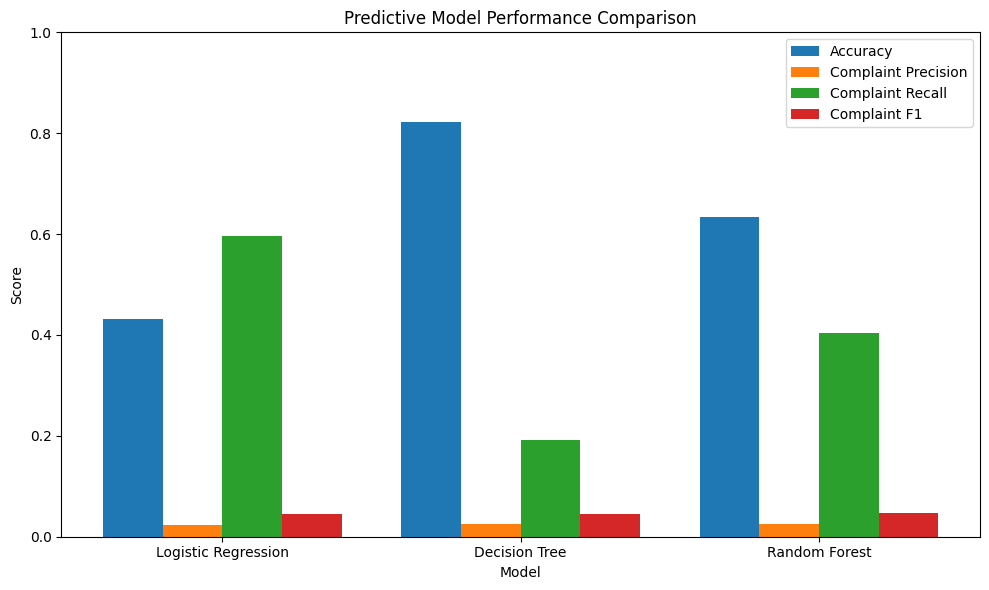

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Logistic Regression", "Decision Tree", "Random Forest"]

accuracy = [0.4319, 0.8223, 0.6335]
precision = [0.0229, 0.0257, 0.0246]
recall = [0.5957, 0.1915, 0.4043]
f1 = [0.0442, 0.0453, 0.0464]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10, 6))

plt.bar(x - 1.5*width, accuracy, width, label="Accuracy")
plt.bar(x - 0.5*width, precision, width, label="Complaint Precision")
plt.bar(x + 0.5*width, recall, width, label="Complaint Recall")
plt.bar(x + 1.5*width, f1, width, label="Complaint F1")

plt.xticks(x, models)
plt.ylabel("Score")
plt.xlabel("Model")
plt.title("Predictive Model Performance Comparison")
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()
plt.savefig(
    "predictive_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()